# GRADTDA5622 - Big Data Computing Foundations 2
## Final Project: Sign Language Translator
Replace the example information below with your real information:
- Semester: Spring 2026 (FILL IN)
- Instructor: Mr. Brad Coy (FILL IN)
- Section: (if applicable)
- Student Name(s): Clayton Morgan, Sam Shomette (FILL IN)
- Student Email(s): morgan.1461@osu.edu,  (FILL IN)
- Student ID(s): 500293216,   (FILL IN)
***

***
# Section: Overview
- Insert a short description of the scope of this exercise, any supporting information, etc.
- **(I will fill this in for each assignment - Tom Bihari)**
***

### Assignment Overview
In this assignment, you will build a sign language translator.

**The Objectives of This Assignment are:**
1. To perform a classification task on image data, using the K-Nearest-Neighbors algorithm from the SciKit-Learn library https://scikit-learn.org/stable/).
2. To understand domain-independent evaluation measures.
3. To understand the impact meta-parameters have in algorithm performance
4. To develop a tool that uses the classification model that was developed.
5. To get practice discussing / explaining your results, findings, and insights.

### Problem Statement
Assume that you are the Director of Data Science for American Signing, Inc. (ASI), a company that provides innovative sign-language solutions.  ASI has new technology that can capture American Sign Language images in real time.  ASI would like your team to design a new product that can translate ASL images to text.

### Things To Do
The follow the instructions for each step in the sections below.

### Notes

- This dataset has exactly the same format as the "standard" MNIST dataset that is widely used.  See the link below for the documentation of the dataset.  You also can search for MNIST in the web.
  - This dataset was pulled on 4/13/23 from: https://www.kaggle.com/code/madz2000/cnn-using-keras-100-accuracy
  - See also: https://en.wikipedia.org/wiki/MNIST_database
  - These are 28x28 gray-scale pixel images, with 256-color (or gray-scale) values.
- You will use the KNN classifier that is provided in the SciKit Learn library (similar to the Case Studies you have done).  You do not need to write your own.
- You will be adjusting the number of training records for the exercise (so it runs reasonably fast), so you do not need to run the algorithm on "all" training records.
- Some code is provided (partially filled in) to assist in the development of the final product - this is a starting point.  You may adjust it as you choose.
- By the way, this exercise is identical to one where, for example, the images are medical scans, etc., and you are trying to classify cells as diseased or healthy.  (There are lots of MNIST examples on the web.)

It is essential that you **communicate** your goals, thought process, actions, results, and conclusions to the **audience** that will consume this work.  It is **not enough** to show just the code.  It is not appropriate to show long sections of **unexplained printout**, etc.  Be kind to your readers and provide value to them!

**ALWAYS follow this pattern** when doing **each portion** of the work.  This allows us to give feedback and assign scores, and to give partial credit.  Make it easy for the reader to understand your work.
- Say (briefly) **what** you are trying to do, and **why**.
- Do it (code).
- Show or describe the **result** clearly (and briefly as needed), and explain the significant **conclusions or insights** derived from the results.

**HAVE FUN!**

***
# Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

In [ ]:
# Convert label numbers 0-25 to characters A-Z
def label_to_letter(label_num):
    return chr(ord('A') + label_num)

# Convert characters A-Z to label numbers 0-25
def letter_to_label(letter):
    return ord(letter) - ord('A')

# Take a numpy array of y labels (true or predicted) and build a string with the decoded letters
def y_labels_to_string(y_array):
    st = ""
    for num in np.nditer(y_array):
        st += label_to_letter(num)
    return st

***
# Read the Data

In [ ]:
# Establish the file path (ONLY edit the user name 'bcoy48', if obtaining from your own forked repo)
fpath = "https://bcoy48.github.io/osu-gradtda-5622-sp25/course_materials/final"

# Read the training data
# train_pdf = pd.read_csv('../shared/sign_mnist_train.csv') [if using an absolute path]
train_pdf = pd.read_csv(f'{fpath}/sign_mnist_train.csv')

In [ ]:
# Read the test data
# test_pdf = pd.read_csv('../shared/sign_mnist_test.csv') [if using an absolute path]
test_pdf = pd.read_csv(f'{fpath}/sign_mnist_test.csv')
test_pdf.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,...,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000
mean,11.247351,147.532627,150.445761,153.324317,155.663413,158.169688,160.790853,162.282766,163.649191,165.589515,...,138.546570,145.539598,150.744980,155.638873,158.893196,159.648494,158.162019,157.672755,156.664250,154.776771
std,7.446712,43.593144,41.867838,40.442728,39.354776,37.749637,36.090916,36.212636,35.885378,33.721876,...,64.501665,65.132370,65.760539,65.565147,65.200300,65.499368,66.493576,66.009690,67.202939,68.285148
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,122.000000,126.000000,130.000000,134.000000,137.000000,141.000000,144.000000,145.000000,147.000000,...,90.000000,95.000000,99.000000,105.000000,113.000000,113.750000,113.000000,115.000000,111.000000,106.750000
50%,11.000000,154.000000,157.000000,159.000000,161.000000,163.000000,165.000000,166.000000,168.000000,169.000000,...,137.000000,155.000000,168.000000,177.000000,181.000000,182.000000,181.000000,180.000000,180.000000,179.000000
75%,18.000000,178.000000,179.000000,181.000000,182.000000,184.000000,185.000000,186.000000,187.000000,187.000000,...,195.000000,200.000000,204.250000,207.000000,207.000000,208.000000,207.000000,205.000000,206.000000,204.000000
max,24.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


***
# Pre-process the Data for Use

In [ ]:
# Normally, you might do EDA here to analyze and handle missing or bad values, transform or eliminate columns, scale values, etc.
# We don't have to do this with this dataset.

In [ ]:
# Split the training and test datasets into X and y parts.
# y contains the labels (first column)
# X contains the attributes (remaining columns of the dataset)

train_row_count = train_pdf.shape[0]  # Gives number of rows
train_col_count = train_pdf.shape[1]  # Gives number of columns
test_row_count  =  test_pdf.shape[0]  # Gives number of rows
test_col_count  =  test_pdf.shape[1]  # Gives number of columns
print(train_row_count,train_col_count,test_row_count,test_col_count)

num_train = 6000  # Trim the number of training rows to use (you will adjust this later when optimizing)
num_test  = 1000  # Trim the number of test rows to use (don't change this)

y_train = train_pdf.iloc[:num_train, 0]
X_train = train_pdf.iloc[:num_train, 1:-1]

y_test = test_pdf.iloc[:num_test, 0]
X_test = test_pdf.iloc[:num_test, 1:-1]

27455 785 7172 785


***
# Run the K-Nearest-Neighbors Algorithm

In [ ]:
# Set a value for K (you will adjust this later when optimizing)
K = 5

In [ ]:
# Initialize the SciKit-Learn classifer and fit the data (train the classifier)
classifier = KNeighborsClassifier(n_neighbors=K, metric='euclidean', weights='distance')
classifier.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

In [ ]:
# Predict the test data
y_pred = classifier.predict(X_test)

In [ ]:
# Compute confusion matrix, classification report, and accuracy score
conf_matrix = confusion_matrix(y_test,y_pred)
classif_report = classification_report(y_test,y_pred)

print('Confusion Matrix (Rows=Actual, Cols=Predicted)')
print(conf_matrix)
print('\nClassification Report')
print(classif_report)
print('\nAccuracy:', accuracy_score(y_test,y_pred))

Confusion Matrix (Rows=Actual, Cols=Predicted)
[[41  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 56  0  3  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  1  1  0  0  0]
 [ 0  0 39  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 31  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  2  0  0  0  0]
 [ 1  0  0  0 59  0  0  0  0  0  0  3  0  0  0  0  0  8  0  0  0  0  0  0]
 [ 0  2  1  0  0 30  0  0  0  0  3  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  1 47  2  0  0  0  1  0  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0  7 52  0  0  0  0  0  0  0  0  0  0  2  0  1  0  0  0]
 [ 2  4  0  0  2  0  0  0 29  0  0  1  1  0  0  0  0  4  0  0  0  0  0  0]
 [ 0  0  0  2  0  0  0  0  1 23  0  0  0  0  0  0  4  0  0  6  3  6  0  0]
 [ 0  0  0  0  0  1  0  3  0  0 17  0  0  0  0  0  0  0  2  0  0  0  0  0]
 [10  0  0  0 12  0  0  0  0  0  0 24 11  0  0  0  0  6  0  0  0  0  0  0]
 [ 2  0  1  0  6  0  0  0  0  0  0  3 17  0  0  2  0 

## Evaluate the classification errors
- Describe the errors qualitatively.  What do you notice?

The errors in the American Sign Language sign detection seems to be driven by visually similar hand shapes.

12 M and 13 N are very similar hand shapes but with 1 finger of difference. This is clear in the confusion matrix as these signs where misattributed to other similar signs, such as M being assigned A and E 22 times.

Since the resolution is limited to 28x28 pixels, this is likely contributing to the misattribution. At this resolution it could be very difficult to pick up on differences like whether a finger is tucked or not in the case of M and N.

In [ ]:
# Show an image taken from a row in an image dataframe (e.g., test_df).
import matplotlib.pyplot as plt
def show_image(caption,pixels):
    plt.figure(figsize=(1, 1))
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.title(caption)
    image = np.asarray(pixels).reshape((28,28))  #print(image.shape)
#    https://matplotlib.org/stable/tutorials/colors/colormaps.html
#    plt.imshow(image, cmap='gray', vmin = 0, vmax = 255, interpolation='none') #with grayscale colormap
    plt.imshow(image) #with default colormap (viridis)
    plt.show()

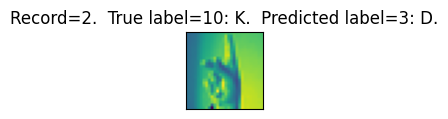

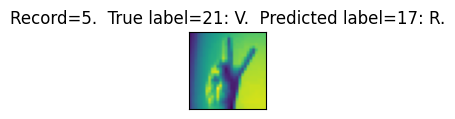

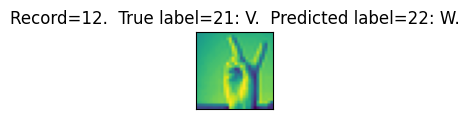

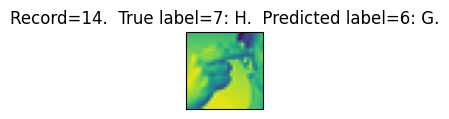

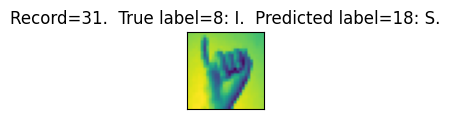

Not all shown.


In [ ]:
# Show test records that are mis-classified.
max_to_show = 5  # Limit the display
shown = 0
for i in range(min(len(y_test), len(y_pred))):
    if(y_pred[i] != y_test[i]):
        my_pred_label = y_pred[i]
        my_true_label  = y_test[i]
        my_pixels = test_pdf.iloc[i,1:]
        caption = "Record=" + str(i) + \
            ".  True label=" +      str(my_true_label) + ": " + label_to_letter(my_true_label) + \
            ".  Predicted label=" + str(my_pred_label) + ": " + label_to_letter(my_pred_label) + "."
        show_image(caption,my_pixels)
        shown += 1
        if shown >= max_to_show:
            print("Not all shown.")
            break

***
# Optimize
- Now we want to see how the behavior of the algorithm changes based on the meta-parameters.  The inputs are:
  - Different values for **K**
  - Different values for **num_train** (number of training records)
- The metrics are:
  - Accuracy
  - Running Time (This is secondary, but helps ensure the processing doesn't take too long.)

## Take the code you created above and make it into a single function with this shape:
- my_accuracy, my_running_time = **run_knn**( K, num_train )

In [ ]:
def run_knn(K,num_train):
  # split training data
  y_train = train_pdf.iloc[:num_train, 0]
  X_train = train_pdf.iloc[:num_train, 1:-1]

  # start timer
  start = time.time()

  # run KNN with K neighbors and same as before
  # then fit to training data and predict
  classifier = KNeighborsClassifier(n_neighbors=K, metric='euclidean', weights='distance')
  classifier.fit(X_train, y_train)
  y_pred = classifier.predict(X_test)

  # end timer
  run_time = time.time() - start

  # accuracy
  acc = accuracy_score(y_test, y_pred)

  # return acc and run time
  return acc, run_time

## Try various values for **K** and graph the results
- Try K = 1-20 or so.
- Use 6000 for num_train
- Choose a "best" value for K

In [ ]:
# Fill in
# set const variables
num_train = 6000
Ks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19 ,20]

# initialize empty accus and time to append to
accus = []
times = []

# loop through each K value
for k in Ks:
  acc, run_time = run_knn(k, num_train)
  accus.append(acc)
  times.append(run_time)

In [ ]:
# print(accus)

Text(0, 0.5, 'Accuracy')

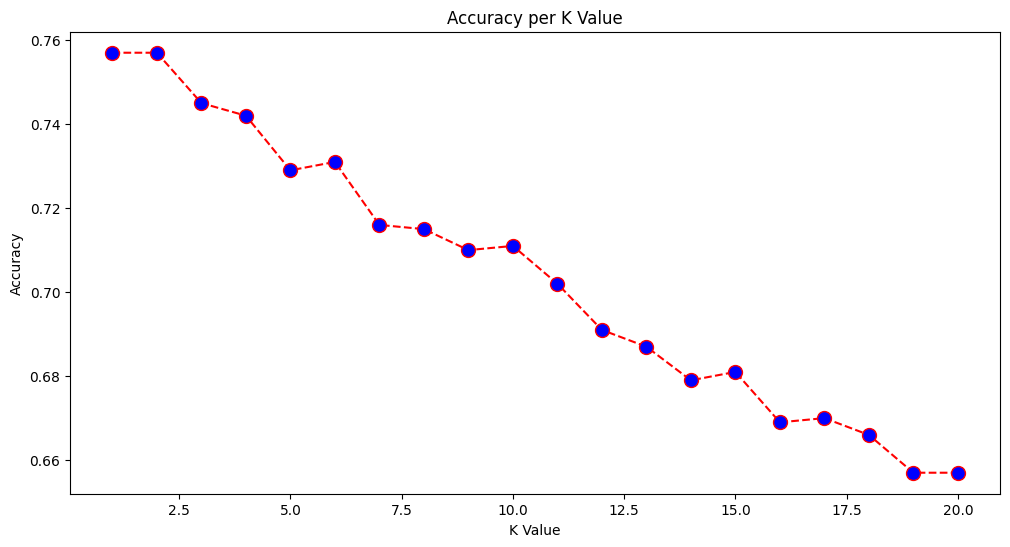

In [ ]:
# Graph Accuracy:
plt.figure(figsize=(12, 6))
plt.plot(Ks, accus, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('Accuracy per K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

Text(0, 0.5, 'Run Time (seconds)')

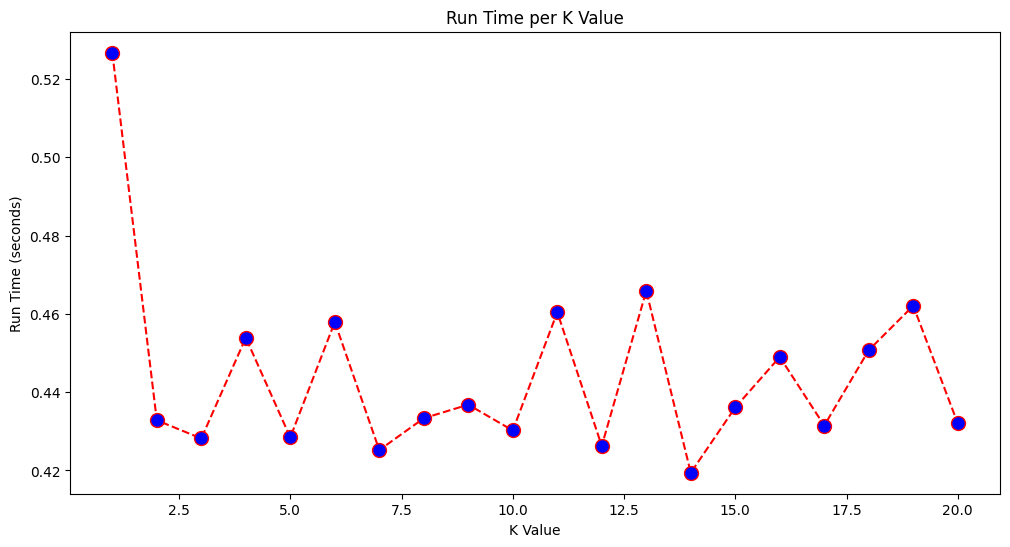

In [ ]:
# also graph run time just to see
plt.figure(figsize=(12, 6))
plt.plot(Ks, times, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('Run Time per K Value')
plt.xlabel('K Value')
plt.ylabel('Run Time (seconds)')

In [ ]:
# Explain, in your words, what you observe in the results.

It is evident that as the k value increases, the overall accuracy decreases. k=1 and k=2 are about equal in terms of accuracy performance, however, it appears that the maximum accuracy is about 0.75.

## Try various values for **num_train** and graph the results
- Try num_train for several values in multiples of 1000.
- Use a value for K that worked well above.
- Choose a "best" value for num_train.

In [ ]:
# Fill in
# Create a list starting at 1000 and up to 25000 in 1000 intervals
num_trains = list(range(1000, 25000, 1000))
# print(num_trains)

# going to use k = 1 for this purpose
k = 1

num_accus = []
num_time = []
# loop through each one and create list of accuracy and runtime
for num in num_trains:
  acc, run_time = run_knn(k, num)
  num_accus.append(acc)
  num_time.append(run_time)

Text(0, 0.5, 'Accuracy')

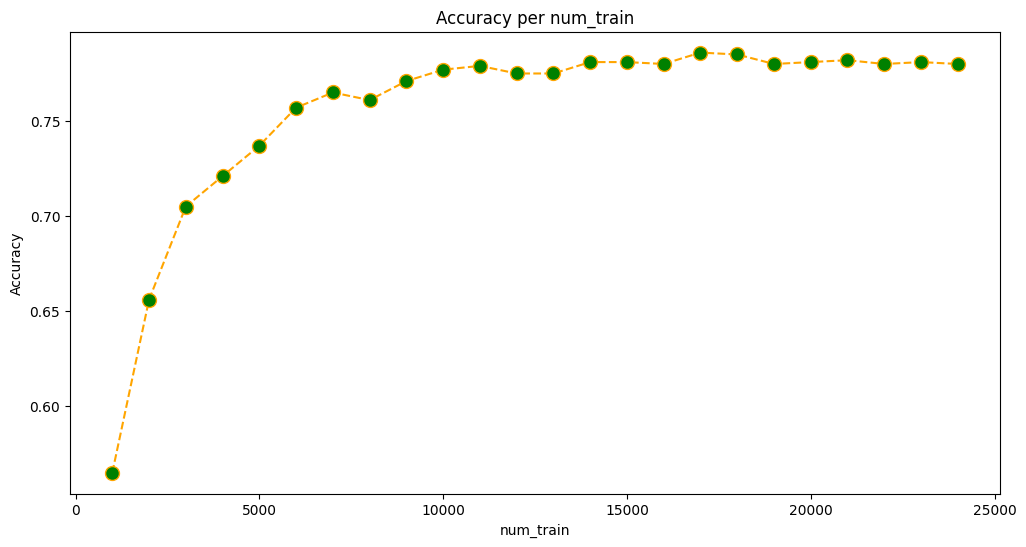

In [ ]:
# Graph Accuracy
plt.figure(figsize=(12, 6))
plt.plot(num_trains, num_accus, color='orange', linestyle='dashed', marker='o', markerfacecolor='green', markersize=10)
plt.title('Accuracy per num_train')
plt.xlabel('num_train')
plt.ylabel('Accuracy')

Text(0, 0.5, 'Run Time')

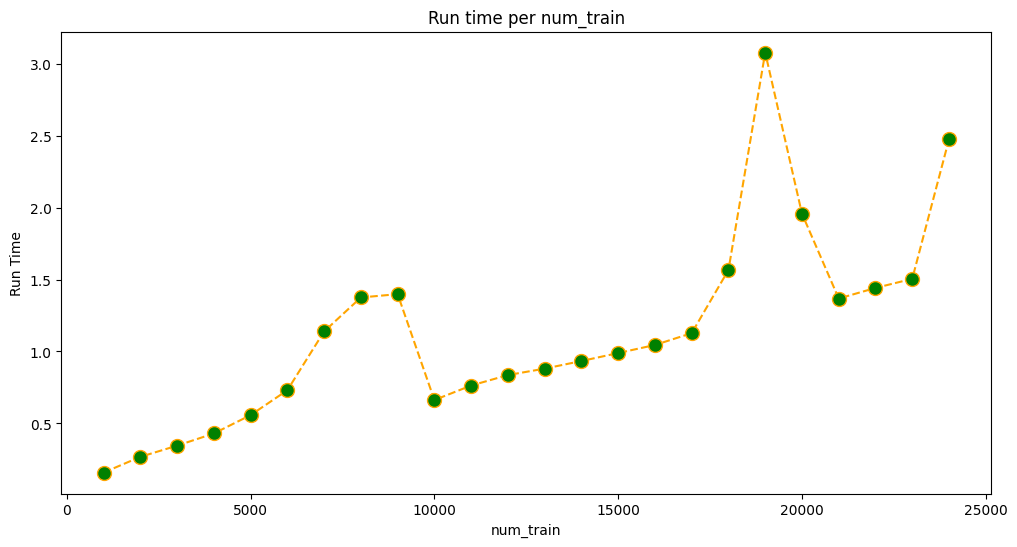

In [ ]:
# graph run time too
plt.figure(figsize=(12, 6))
plt.plot(num_trains, num_time, color='orange', linestyle='dashed', marker='o', markerfacecolor='green', markersize=10)
plt.title('Run time per num_train')
plt.xlabel('num_train')
plt.ylabel('Run Time')

In [ ]:
# Explain, in your words, what you observe in the results.

17000 for num_train appears to be the sweet spot of both peak accuracy and still having a generally low run time. As the num_train increases there is a sharp increase in accuracy and it plateaus around 7000 - 10000. From here there is a clear diminishing return of adding more with little gain.

***
# Create a Sign Language to Text Translator
- Now we want to build a translator that takes as input a CSV file of sign language images and prints out the corresponding text.
- The translator will work as follows:
  - Based on the experiments you ran above, choose a "best" K value and "num_train" value.
  - Create a new classifier using these parameters and train it on the training data (as you did above).
  - Create a function "translate_signs_to_text" that processes a CSV file of images.

## Based on the code you created above and make it into a single function with this shape:


In [ ]:
# Initialize a SciKit-Learn classifer and fit the data (train the classifier)
#   with the "best" configuration parameters you "chose" above.

chosen_K = 2        # Fill this in
chosen_num_train = 17000  # Fill this in

y_train = train_pdf.iloc[:chosen_num_train, 0]
X_train = train_pdf.iloc[:chosen_num_train, 1:-1]

chosen_classifier = KNeighborsClassifier(n_neighbors=chosen_K, metric='euclidean', weights='distance')
chosen_classifier.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=2, weights='distance')

In [ ]:
# Fill in this function
def translate_signs_to_text(input_sign_csv_filename):
    # read the CSV file
    input_pdf = pd.read_csv(input_sign_csv_filename)

    # create X and y tables from the dataframe
    y_true = input_pdf.iloc[:, 0]
    X      = input_pdf.iloc[:, 1:-1]

    # predict the y values
    y_pred = chosen_classifier.predict(X)

    # return the true text, predicted text, and the accuracy
    accuracy = accuracy_score(y_true, y_pred)
    true_text = y_labels_to_string(y_true)
    pred_text = y_labels_to_string(y_pred)
    return true_text, pred_text, accuracy

In [ ]:
# Translate Message1
# true_text, pred_text, acc = translate_signs_to_text('../shared/sign_mnist_message1.csv') [if using an absolute path]
true_text, pred_text, acc = translate_signs_to_text('../content/sign_mnist_message1.csv')
print("PRED:",pred_text)
# Guess the actual message.

PRED: GOBUCVERES


In [ ]:
# Now print the true message and the accuracy.  Were you right?
print("TRUE:",true_text)
print("ACC: ",acc)

TRUE: GOBUCKEYES
ACC:  0.8


In [ ]:
# Translate Message2
# true_text, pred_text, acc = translate_signs_to_text('../shared/sign_mnist_message2.csv') [if using an absolute path]
true_text, pred_text, acc = translate_signs_to_text('/content/sign_mnist_message2.csv')
print("PRED:",pred_text)
# Guess the actual message.

PRED: HAPPRSUMMEU


In [ ]:
# Now print the true message and the accuracy.  Were you right?
print("TRUE:",true_text)
print("ACC: ",acc)

TRUE: HAPPYSUMMER
ACC:  0.8181818181818182


In [ ]:
# Translate Message3
# true_text, pred_text, acc = translate_signs_to_text('../shared/sign_mnist_message3.csv') [if using an absolute path]
true_text, pred_text, acc = translate_signs_to_text('/content/sign_mnist_message3.csv')
print("PRED:",pred_text)
# Guess the actual message.

PRED: CALLMEISHMAELSOMEREAUSAGOSEUEUMISDHOWLOSGPUECISELRHAUISGLITTLEOUSOMOSERISMRPUUSEASDSOTHISGPAUTICULAUTOISTEUESTMEOSSHOUEITHOUGHTIWOULDSAILABOUTALITTLEASDSEETHEWATEURPAUTOFTHEWOULD


In [ ]:
# Now print the true message and the accuracy.  Were you right?  (What is the source of this quote?)
print("TRUE:",true_text)
print("ACC: ",acc)

TRUE: CALLMEISHMAELSOMEYEARSAGONEVERMINDHOWLONGPRECISELYHAVINGLITTLEORNOMONEYINMYPURSEANDNOTHINGPARTICULARTOINTERESTMEONSHOREITHOUGHTIWOULDSAILABOUTALITTLEANDSEETHEWATERYPARTOFTHEWORLD
ACC:  0.8202247191011236


***
# Optional Extra Credit: Create a Text to Sign Language Translator
- Now we want to build a translator function that takes as input a text string and outputs a CSV file of sign language images.
  - Create a function "translate_text_to_signs" as below.
  - Try the translator on several text strings (and use the translate_signs_to_text function above to check the results).

In [ ]:
def translate_text_to_signs(input_string, output_sign_csv_filename):
    # Hints:
    # Create a blank dataframe of the same shape as the dataframes above.
    # For each character in the input string:
    #   Find a row in an existing dataframe that matches that character.
    #   Copy that row to the new dataframe.
    # Write the final dataframe to the CSV file.
    return

***
# Write a summary of what you have learned in this exercise.

In [ ]:
# Add your text here

From this exercise we have learned how to build a data driven solution end to end. This exercise has provided the opportunity to evaluate the performance of a predictive model. Using a plot to determine the most effective parameters for the learning model.

A big takeaway is that the model here relies heabily on strong and structured training data. Accuracy in this situation can be limited by a variety of factors, but the model was able to get to about a 80% accuracy rate even with only a 28x28 pixel input.

By comparing the text to the true text, it is possible to determine the accuracy, but this does not capture all possible errors. As even a very small error in this model can completely change the meaning of a result.

Overall, this project has shown the power and limitations of machine learning approaches for image recognition.